In [23]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

### Path specification

In [24]:
dataset = 'keypoint_samples.csv'
model_save_path = 'keypoint_classifier.keras'
tflite_save_path = 'keypoint_classifier.tflite'

### Set number of classes

In [25]:
NUM_CLASSES = 12

### Dataset reading

In [26]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [27]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

### Model building

In [29]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_2 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,202 (4.70 KB)

 Trainable params: 1,202 (4.70 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [32]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Model training

In [33]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
60/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0807 - loss: 2.5157  
Epoch 1: saving model to keypoint_classifier.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0849 - loss: 2.5038 - val_accuracy: 0.1527 - val_loss: 2.3955
Epoch 2/1000
81/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1509 - loss: 2.3800
Epoch 2: saving model to keypoint_classifier.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1513 - loss: 2.3791 - val_accuracy: 0.2233 - val_loss: 2.2611
Epoch 3/1000
47/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1938 - loss: 2.2734 
Epoch 3: saving model to keypoint_classifier.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1947 - loss: 2.2598 - val_accuracy: 0.2600 - val_loss: 2.0859
Epoch 4/1000
65/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2421 - loss: 2.1374
Epoch 4: saving model to keypoint_classifier.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2429 - loss: 2.1300 - val_accuracy: 0.3204 - val_lo

In [34]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8726 - loss: 0.5528 


In [35]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [36]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[7.1019685e-06 6.1632827e-02 4.0673948e-10 6.9346225e-07 4.5774085e-03
 7.6356563e-03 1.0639866e-01 6.0630059e-01 1.8841232e-01 2.4745086e-02
 2.5931236e-04 3.0283281e-05]
7


### Confusion matrix

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


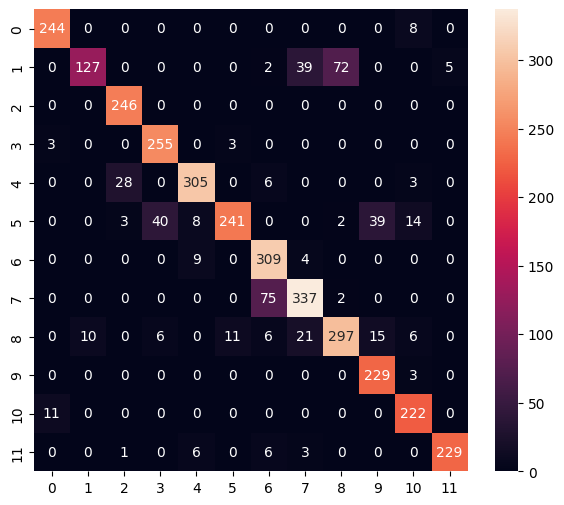

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       252
           1       0.93      0.52      0.66       245
           2       0.88      1.00      0.94       246
           3       0.85      0.98      0.91       261
           4       0.93      0.89      0.91       342
           5       0.95      0.69      0.80       347
           6       0.76      0.96      0.85       322
           7       0.83      0.81      0.82       414
           8       0.80      0.80      0.80       372
           9       0.81      0.99      0.89       232
          10       0.87      0.95      0.91       233
          11       0.98      0.93      0.96       245

    accuracy                           0.87      3511
   macro avg       0.88      0.87      0.87      3511
weighted avg       0.87      0.87      0.86      3511



In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

### Convert to model for Tensorflow-Lite

In [38]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [39]:
# Convert model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\renat\AppData\Local\Temp\tmp_q02p2wa\assets


INFO:tensorflow:Assets written to: C:\Users\renat\AppData\Local\Temp\tmp_q02p2wa\assets


Saved artifact at 'C:\Users\renat\AppData\Local\Temp\tmp_q02p2wa'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  2769966174416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2769966179600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2769966178448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2769966177296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2769966176144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2769966185744: TensorSpec(shape=(), dtype=tf.resource, name=None)


6892

### Inference test

In [40]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [41]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [42]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [43]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [44]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[7.10195582e-06 6.16328195e-02 4.06738698e-10 6.93461629e-07
 4.57740482e-03 7.63565302e-03 1.06398724e-01 6.06300652e-01
 1.88412294e-01 2.47450843e-02 2.59312015e-04 3.02832850e-05]
7
